# W02 Algorithm Benchmarks

This notebook benchmarks the Week 2 physical-AI algorithm primitives:

1. Sliding-window telemetry preprocessing
2. Sparse 2D spatial index
3. Priority/deadline task scheduler

The goal is not to reproduce robot intelligence. The goal is to compare simple baseline implementations against bounded, testable algorithmic utilities that could support a future physical-AI decision loop.

Run this notebook from the repository root after installing the project:

```bash
python -m pip install -e ".[dev]"
```


In [1]:
from __future__ import annotations

import heapq
import math
import random
import time
from collections.abc import Callable
from dataclasses import dataclass

import matplotlib.pyplot as plt
import pandas as pd

from ingen_pydev.algo.sliding_window import SlidingWindowTelemetry
from ingen_pydev.algo.spatial_index import SpatialIndex2D
from ingen_pydev.algo.task_scheduler import Task, TaskScheduler

random.seed(42)


In [2]:
def time_run(fn: Callable[[], object], repeats: int = 5) -> float:
    """Return the best runtime across repeated runs."""
    best = float("inf")
    for _ in range(repeats):
        start = time.perf_counter()
        fn()
        elapsed = time.perf_counter() - start
        best = min(best, elapsed)
    return best


## 1. Sliding Window Telemetry

The naive implementation recomputes mean and standard deviation by scanning the full window for every new reading. This costs `O(n·k)`, where `n` is the number of readings and `k` is the window size.

The optimized implementation keeps a deque, running sum, and running sum of squares. Each new reading updates the rolling statistics in `O(1)`, so total processing is `O(n)`.

Important: this benchmark compares equal work. Both versions compute rolling mean and rolling standard deviation.


In [3]:
def naive_sliding_window_full(
    values: list[float], window_size: int
) -> list[tuple[float, float]]:
    """Naive rolling mean/std by rescanning the whole window each step."""
    results: list[tuple[float, float]] = []

    for i in range(len(values)):
        start = max(0, i - window_size + 1)
        window = values[start : i + 1]

        mean = sum(window) / len(window)
        variance = sum((x - mean) ** 2 for x in window) / len(window)
        std = variance**0.5
        results.append((mean, std))

    return results


def optimized_sliding_window_full(
    values: list[float], window_size: int
) -> list[tuple[float, float]]:
    """Optimized rolling mean/std using the Week 2 module."""
    telemetry = SlidingWindowTelemetry(window_size=window_size)
    results: list[tuple[float, float]] = []

    for value in values:
        stats = telemetry.add(value)
        results.append((stats.mean, stats.std))

    return results


In [4]:
window_size = 1_000
sliding_sizes = [1_000, 5_000, 10_000, 50_000, 100_000]

sliding_results = []

for n in sliding_sizes:
    values = [random.gauss(50.0, 5.0) for _ in range(n)]

    naive_time = time_run(
        lambda: naive_sliding_window_full(values, window_size), repeats=3
    )
    optimized_time = time_run(
        lambda: optimized_sliding_window_full(values, window_size), repeats=3
    )

    sliding_results.append(
        {
            "module": "sliding_window",
            "n": n,
            "window_size": window_size,
            "naive_seconds": naive_time,
            "optimized_seconds": optimized_time,
            "speedup": naive_time / optimized_time
            if optimized_time > 0
            else float("inf"),
        }
    )

sliding_df = pd.DataFrame(sliding_results)
sliding_df


,module,n,window_size,naive_seconds,optimized_seconds,speedup
0,sliding_window,1000,1000,0.065164,0.001541,42.283822
1,sliding_window,5000,1000,0.602568,0.010619,56.745910
2,sliding_window,10000,1000,1.113515,0.017963,61.987987
3,sliding_window,50000,1000,5.841277,0.092323,63.270281
4,sliding_window,100000,1000,13.221948,0.221066,59.809958


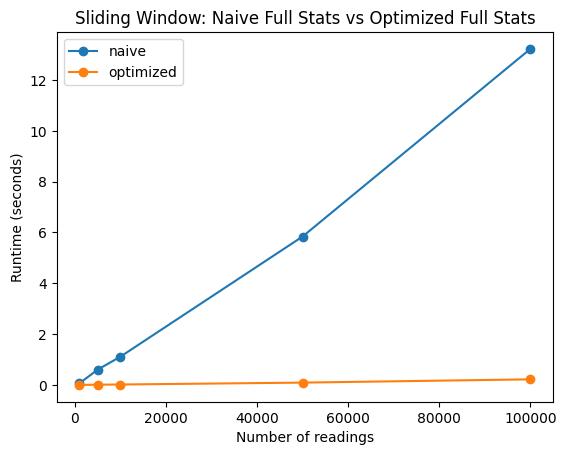

In [5]:
plt.figure()
plt.plot(sliding_df["n"], sliding_df["naive_seconds"], marker="o", label="naive")
plt.plot(
    sliding_df["n"],
    sliding_df["optimized_seconds"],
    marker="o",
    label="optimized",
)
plt.xlabel("Number of readings")
plt.ylabel("Runtime (seconds)")
plt.title("Sliding Window: Naive Full Stats vs Optimized Full Stats")
plt.legend()
plt.show()


## 2. Sparse 2D Spatial Index

The brute-force baseline checks the distance from the query anchor to every item. This costs `O(n)` per query.

The grid index stores sparse entities in grid buckets. For a radius query, it only checks nearby buckets and then applies exact distance filtering. This is useful for nearby robot, alert, task, obstacle, or charging-station lookup in a shared 2D coordinate frame.

This benchmark assumes spatially sparse points and a query radius that is small relative to the world size. If all points fall into the same bucket, the grid index can degrade toward brute-force behavior.


In [6]:
@dataclass(frozen=True)
class Point:
    item_id: str
    x: float
    y: float
    kind: str | None = None


def brute_force_radius_query(
    points: list[Point], x: float, y: float, radius: float
) -> list[Point]:
    radius_sq = radius * radius
    results: list[Point] = []

    for point in points:
        dx = point.x - x
        dy = point.y - y
        if dx * dx + dy * dy <= radius_sq:
            results.append(point)

    return results


def build_points(n: int, world_size: float = 10_000.0) -> list[Point]:
    kinds = ["robot", "alert", "charger", "task"]
    return [
        Point(
            item_id=f"item_{i}",
            x=random.uniform(0, world_size),
            y=random.uniform(0, world_size),
            kind=random.choice(kinds),
        )
        for i in range(n)
    ]


def build_index(points: list[Point], cell_size: float) -> SpatialIndex2D:
    index = SpatialIndex2D(cell_size=cell_size)

    for point in points:
        index.insert(point.item_id, point.x, point.y, kind=point.kind)

    return index


In [7]:
spatial_sizes = [1_000, 5_000, 10_000, 50_000]
query_count = 500
radius = 50.0
cell_size = 50.0
world_size = 10_000.0

spatial_results = []

for n in spatial_sizes:
    points = build_points(n, world_size=world_size)
    index = build_index(points, cell_size=cell_size)

    queries = [
        (random.uniform(0, world_size), random.uniform(0, world_size))
        for _ in range(query_count)
    ]

    brute_time = time_run(
        lambda: [brute_force_radius_query(points, x, y, radius) for x, y in queries],
        repeats=3,
    )

    index_time = time_run(
        lambda: [index.query_radius(x, y, radius) for x, y in queries],
        repeats=3,
    )

    spatial_results.append(
        {
            "module": "spatial_index",
            "n": n,
            "queries": query_count,
            "brute_force_seconds": brute_time,
            "grid_index_seconds": index_time,
            "speedup": brute_time / index_time if index_time > 0 else float("inf"),
        }
    )

spatial_df = pd.DataFrame(spatial_results)
spatial_df


,module,n,queries,brute_force_seconds,grid_index_seconds,speedup
0,spatial_index,1000,500,0.043438,0.001068,40.664762
1,spatial_index,5000,500,0.188416,0.001453,129.700557
2,spatial_index,10000,500,0.462375,0.001747,264.637701
3,spatial_index,50000,500,1.985639,0.006336,313.365328


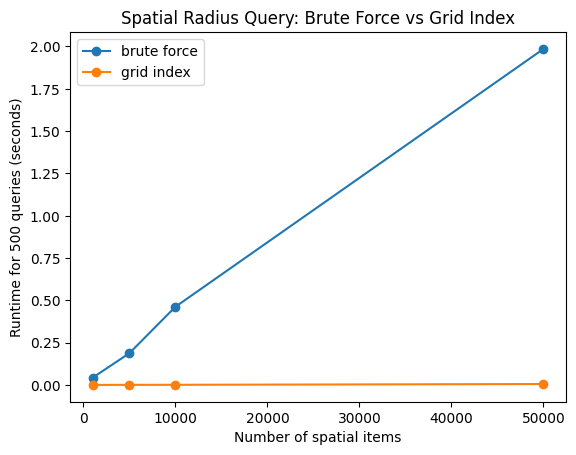

In [8]:
plt.figure()
plt.plot(
    spatial_df["n"],
    spatial_df["brute_force_seconds"],
    marker="o",
    label="brute force",
)
plt.plot(
    spatial_df["n"],
    spatial_df["grid_index_seconds"],
    marker="o",
    label="grid index",
)
plt.xlabel("Number of spatial items")
plt.ylabel("Runtime for 500 queries (seconds)")
plt.title("Spatial Radius Query: Brute Force vs Grid Index")
plt.legend()
plt.show()


## 3. Priority Task Scheduler

The naive baseline sorts the full task list every time a task is popped. This is simple but expensive.

The optimized scheduler uses a heap. Adding a task costs `O(log n)`, and popping the next valid task costs `O(log n)` amortized. This fits a robot task queue where tasks already have upstream priority and deadline values.


In [9]:
def naive_sort_scheduler(tasks: list[Task], now: float) -> list[Task]:
    pending = tasks[:]
    popped: list[Task] = []

    while pending:
        valid = [task for task in pending if task.deadline >= now]
        if not valid:
            break

        valid.sort(key=lambda task: (-task.priority, task.deadline, task.created_at))
        next_task = valid[0]
        popped.append(next_task)
        pending.remove(next_task)

    return popped


def heap_scheduler(tasks: list[Task], now: float) -> list[Task]:
    scheduler = TaskScheduler()

    for task in tasks:
        scheduler.add_task(task)

    popped: list[Task] = []

    while True:
        task = scheduler.pop_next(now=now)
        if task is None:
            break
        popped.append(task)

    return popped


def build_tasks(n: int) -> list[Task]:
    return [
        Task(
            task_id=f"task_{i}",
            priority=random.randint(1, 100),
            deadline=random.uniform(100.0, 1_000.0),
            created_at=float(i),
            payload={"target": [random.random(), random.random()]},
        )
        for i in range(n)
    ]


In [11]:
task_sizes = [1_000, 2_500, 5_000, 10_000]

scheduler_results = []

for n in task_sizes:
    tasks = build_tasks(n)

    naive_time = time_run(lambda: naive_sort_scheduler(tasks, now=0.0), repeats=3)
    heap_time = time_run(lambda: heap_scheduler(tasks, now=0.0), repeats=3)

    scheduler_results.append(
        {
            "module": "task_scheduler",
            "n": n,
            "naive_sort_seconds": naive_time,
            "heap_seconds": heap_time,
            "speedup": naive_time / heap_time if heap_time > 0 else float("inf"),
        }
    )

scheduler_df = pd.DataFrame(scheduler_results)
scheduler_df


,module,n,naive_sort_seconds,heap_seconds,speedup
0,task_scheduler,1000,0.220753,0.000521,423.872114
1,task_scheduler,2500,1.438461,0.001531,939.495290
2,task_scheduler,5000,6.465786,0.003033,2131.741890
3,task_scheduler,10000,31.680061,0.018804,1684.769106


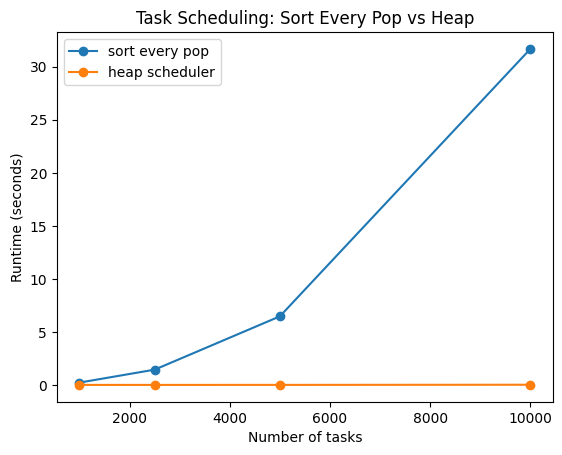

In [12]:
plt.figure()
plt.plot(
    scheduler_df["n"],
    scheduler_df["naive_sort_seconds"],
    marker="o",
    label="sort every pop",
)
plt.plot(
    scheduler_df["n"],
    scheduler_df["heap_seconds"],
    marker="o",
    label="heap scheduler",
)
plt.xlabel("Number of tasks")
plt.ylabel("Runtime (seconds)")
plt.title("Task Scheduling: Sort Every Pop vs Heap")
plt.legend()
plt.show()


## Summary Table


In [13]:
summary = pd.DataFrame(
    [
        {
            "module": "sliding_window",
            "baseline": "recompute window mean/std",
            "optimized": "deque + running sums",
            "baseline_complexity": "O(n·k)",
            "optimized_complexity": "O(n)",
        },
        {
            "module": "spatial_index",
            "baseline": "scan all points per query",
            "optimized": "sparse grid bucket lookup",
            "baseline_complexity": "O(n) per query",
            "optimized_complexity": "O(c + m) per query",
        },
        {
            "module": "task_scheduler",
            "baseline": "sort pending tasks every pop",
            "optimized": "heap priority queue",
            "baseline_complexity": "O(n log n) per pop",
            "optimized_complexity": "O(log n) per add/pop",
        },
    ]
)

summary


,module,baseline,optimized,baseline_complexity,optimized_complexity
0,sliding_window,recompute window mean/std,deque + running sums,O(n·k),O(n)
1,spatial_index,scan all points per query,sparse grid bucket lookup,O(n) per query,O(c + m) per query
2,task_scheduler,sort pending tasks every pop,heap priority queue,O(n log n) per pop,O(log n) per add/pop


## Week 2 Benchmark Conclusion

The Week 2 modules are intentionally simple algorithmic primitives, not full robot intelligence modules.

The sliding-window telemetry module shows how a streaming sensor signal can be summarized in constant time per reading instead of recomputing over the full window.

The spatial index shows how nearby-entity queries can avoid scanning the entire world state by using sparse grid buckets.

The task scheduler shows how a heap can replace repeated full sorting when dispatching priority/deadline tasks.

Together, these modules form a public-safe middleware foundation for a future physical-AI decision loop: telemetry health, nearby entity lookup, and task dispatch.
